Links:
 - https://stackoverflow.com/questions/78106951/how-do-i-access-input-devices-on-wsl2
 - https://www.pygame.org/docs/ref/midi.html

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
from scipy.io.wavfile import write
from IPython.display import Audio

In [67]:
def generate_symbolic_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")
triangle_wave = generate_symbolic_triangle_wave()

def generate_symbolic_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")
sawtooth_wave = generate_symbolic_sawtooth_wave()

def generate_symbolic_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")
square_wave = generate_symbolic_square_wave()
# Add an option to vary the duty cycle. Could also add this to the other waveforms.

def generate_symbolic_adsr():
    x, attack_duration, decay_duration, sustain_duration, sustain_level, release_duration = sy.symbols("x attack_duration decay_duration sustain_duration sustain_level release_duration")
    attack_start, attack_end = 0, attack_duration
    decay_start, decay_end = attack_end, attack_end + decay_duration
    sustain_start, sustain_end, sustain = decay_end, decay_end + sustain_duration, sustain_level
    release_start, release_end = sustain_end, sustain_end + release_duration
    
    attack_condition = (attack_start < x) & (x <= attack_end)
    decay_condition = (decay_start < x) & (x <= decay_end)
    sustain_condition = (sustain_start < x) & (x <= sustain_end)
    release_condition = (release_start < x) & (x <= release_end)
    
    x_attack = 2*(x - attack_start)/(attack_end - attack_start) - 1
    attack = -(x_attack**3 - 3*x_attack - 2)/4
    
    x_decay = 2*(x - decay_start)/(decay_end - decay_start) - 1
    decay = -(((-x_decay)**3 - 3*(-x_decay) - 2)/4)*(1 - sustain) + sustain
    
    x_release = 2*(x - release_start)/(release_end - release_start) - 1
    release = -(((-x_release)**3 - 3*(-x_release) - 2)/4)*sustain
    
    y = sy.Piecewise((0, (x <= attack_start)), (attack, attack_condition), (decay, decay_condition), (sustain, sustain_condition), (release, release_condition), (0, (release_end < x)))
    return sy.lambdify((x, attack_duration, decay_duration, sustain_duration, sustain_level, release_duration), y, "numpy")
symbolic_adsr = generate_symbolic_adsr()
# This implementation of the ADSR is different from the standard implementation. 
# Normally, the attack_duration, decay_duration and release_duration would be defined in seconds, the attack then decay would trigger when the note is pressed, the sustain would continue while the note is held and the release would trigger when the note is released.
# You don't need to change the generate_symbolic_adsr function, just change the ADSR class below. Maybe add "ratio" and "durations" arguments so you can define it either way.
# Having the release continue after the note is released will require some more work. 

In [132]:
class Oscillator():
    def __init__(self, waveform = "sine", pitch = "C4", volume = 1, sample_rate = 44100):
        musical_alphabet = ["C", "C#/Db", "D", "Eb/D#", "E", "F", "F#/Gb", "G", "Ab/G#", "A", "Bb/A#", "B"]
        frequencies = [440*(2**((m - 69)/12)) for m in range(12, 120)]
        self.notes_lut = {}
        octaves = (np.floor(np.arange(12, 120)/12) - 1).astype(int)
        for index, (frequency, octave) in enumerate(zip(frequencies, octaves)):
            note = musical_alphabet[index%12] + str(octave)
            self.notes_lut[note] = frequency
        self.waveform = waveform
        self.pitch = pitch
        self.volume = volume
        self.sample_rate = sample_rate
    
    def generate_pitch(self, duration = None, samples = None):
        if duration and samples:
            raise Exception("Both duration and samples cannot be specified!")
        elif not duration and not samples:
            raise Exception("Either duration or samples must be specified!")
        elif duration:
            samples = int(self.sample_rate*duration)
        elif samples:
            duration = samples/self.sample_rate
        if self.pitch is None:
            return np.zeros(samples)
        else:
            return self.volume*self.waveform(np.linspace(0, self.pitch*duration*2*np.pi, samples))
    
    @property
    def pitch(self):
        return self._pitch
    @pitch.setter
    def pitch(self, pitch):
        if type(pitch) in [str, np.str_]:
            self._pitch = self.notes_lut[pitch.upper()]
        elif type(pitch) in [int, float]:
            self._pitch = pitch
        elif pitch is None:
            self._pitch = None
        else:
            raise Exception("Invalid pitch! Must be either a string, a number or None!")
    
    @property
    def waveform(self):
        return self._waveform
    @waveform.setter
    def waveform(self, waveform):
        if waveform == "sine":
            self._waveform = np.sin
        elif waveform == "triangle":
            self._waveform = triangle_wave
        elif waveform == "sawtooth":
            self._waveform = sawtooth_wave
        elif waveform == "square":
            self._waveform = square_wave
        else:
            raise Exception("Invalid waveform!, must be either 'sine', 'triangle', 'sawtooth' or 'square'!")

class ADSR():
    def __init__(self, attack = 0.25, decay = 0.25, sustain = 0.25, sustain_level = 0.5, release = 0.25):
        self.duration = attack + decay + sustain + release
        self.attack = attack/self.duration
        self.decay = decay/self.duration
        self.sustain = sustain/self.duration
        self.sustain_level = sustain_level
        self.release = release/self.duration
        self.adsr = self._generate_adsr()
        
    def _generate_adsr(self):
        def adsr(x):
            return symbolic_adsr(x, self.attack, self.decay, self.sustain, self.sustain_level, self.release)
        return adsr
    
    def apply(self, wave):
        return self.adsr(np.linspace(0, 1, wave.size))*wave

class Filter():
    def __init__(self, kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = 44100):
        self.duration = duration
        self.width = width
        self.sample_rate = sample_rate
        self.kernel_type = kernel_type
        self.kernel = self._kernel_low_pass()

    def _kernel_low_pass(self):
        def gaussian(x, sigma):
            return np.exp(-0.5*x**2/(sigma**2))
        width = self.width*2*np.pi
        samples = int(self.duration*self.sample_rate)
        domain = np.linspace(-width/2, width/2, samples)
        kernel = np.sinc(domain)*gaussian(domain, width/6)
        return kernel/np.abs(np.fft.fft(kernel)[0])
    
    def apply(self, wave):
        return np.convolve(wave, self.kernel, mode = "same")

    @property
    def kernel_type(self):
        return self._kernel_type
    @kernel_type.setter
    def kernel_type(self, kernel_type):
        if kernel_type.lower() not in ["low-pass"]:
            raise Exception("Invalid kernel type! Must be either 'low-pass', some other type, another type, yet another, etc.!")
        self._kernel_type = kernel_type
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def duration(self):
        return self._duration
    @duration.setter
    def duration(self, duration):
        self._duration = duration
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def width(self):
        return self._width
    @width.setter
    def width(self, width):
        self._width = width
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def sample_rate(self):
        return self._sample_rate
    @sample_rate.setter
    def sample_rate(self, sample_rate):
        self._sample_rate = sample_rate
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()

class Bar():
    def __init__(self, notes, note_values, time_signature = (4, 4)):
        self.notes = notes
        self.note_values = note_values
        self.time_signature = time_signature
        self._exception_check()
    
    def _exception_check(self):
        if np.array([True if hasattr(self, attribute) else False for attribute in ["notes", "note_values", "time_signature"]]).all():
            if self.notes.size != self.note_values.size:
                raise Exception("Number of notes must be equal to the number of note values!")
            elif self.notes.size < self.time_signature[0]:
                raise Exception("Too few notes in the bar!")
            elif self.notes.size > self.time_signature[0]:
                raise Exception("Too many notes in the bar!")
            elif self.note_values.sum() != self.time_signature[0]/self.time_signature[1]:
                raise Exception("Note values must sum to the length of the bar specified in the time signature!")
    
    @property
    def notes(self):
        return self._notes
    @notes.setter
    def notes(self, notes):
        self._notes = np.array(notes) if type(notes) != np.ndarray else notes
        self._exception_check()
    
    @property
    def note_values(self):
        return self._note_values
    @note_values.setter
    def note_values(self, note_values):
        self._note_values = np.array(note_values) if type(note_values) != np.ndarray else note_values
        self._exception_check()

def calculate_note_sample_masks(bar, bpm, sample_rate = 44100):
    bar_duration = bar.time_signature[0]*60/bpm
    bar_samples = int(bar_duration*sample_rate)
    beat_samples = bar_samples*bar.time_signature[1]/bar.time_signature[0]
    note_sample_mask = np.full((bar.notes.size, bar_samples), False)
    for index, note_value in enumerate(bar.note_values):
        mask_start = np.floor(bar.note_values[:index].sum()*beat_samples).astype(int)
        mask_end = mask_start + np.floor(note_value*beat_samples).astype(int)
        note_sample_mask[index, mask_start:mask_end] = True
    return note_sample_mask

def generate_wave(bar, oscillators, adsrs, filters, bpm, sample_rate = 44100):
    if type(oscillators) not in [list, tuple]:
        oscillators = [oscillators for _ in range(bar.notes.size)]
    if type(adsrs) not in [list, tuple]:
        adsrs = [adsrs for _ in range(bar.notes.size)]
    if type(filters) not in [list, tuple]:
        filters = [filters for _ in range(bar.notes.size)]
    note_sample_masks = calculate_note_sample_masks(bar, bpm, sample_rate = sample_rate)
    waves = np.zeros(note_sample_masks.shape)
    for index, note_sample_mask in enumerate(note_sample_masks):
        note_samples = note_sample_mask.sum()
        if oscillators[index] is not None:
            oscillators[index].pitch = bar.notes[index]
            wave = oscillators[index].generate_pitch(samples = note_samples)
        else:
            wave = np.zeros(note_samples)
        if adsrs[index] is not None:
            wave = adsrs[index].apply(wave)
        if filters[index] is not None:
            wave = filters[index].apply(wave)
        waves[index][note_sample_mask] = wave
    return waves.sum(0)

def generate_pause(value, time_signature, bpm, sample_rate = 44100):
    duration = value*time_signature[1]*60/bpm
    samples = int(duration*sample_rate)
    return np.zeros(samples)

def save(file_name, array_input, sample_rate = 44100):
    array_input_range = np.ptp(array_input)
    if array_input.ndim == 2:
        array_output = array_input.sum(0)
    else:
        array_output = array_input.copy()
    array_output -= array_output.min()
    array_output *= (2**32 - 1)/array_output.max()
    array_output -= (2**32)//2
    array_output *= array_input_range/2
    array_output = np.clip(array_output, -2**32//2, 2**32//2 - 1).astype(np.int32).T
    if file_name[-4:] != ".wav":
        file_name += ".wav"
    write(file_name, sample_rate, array_output)

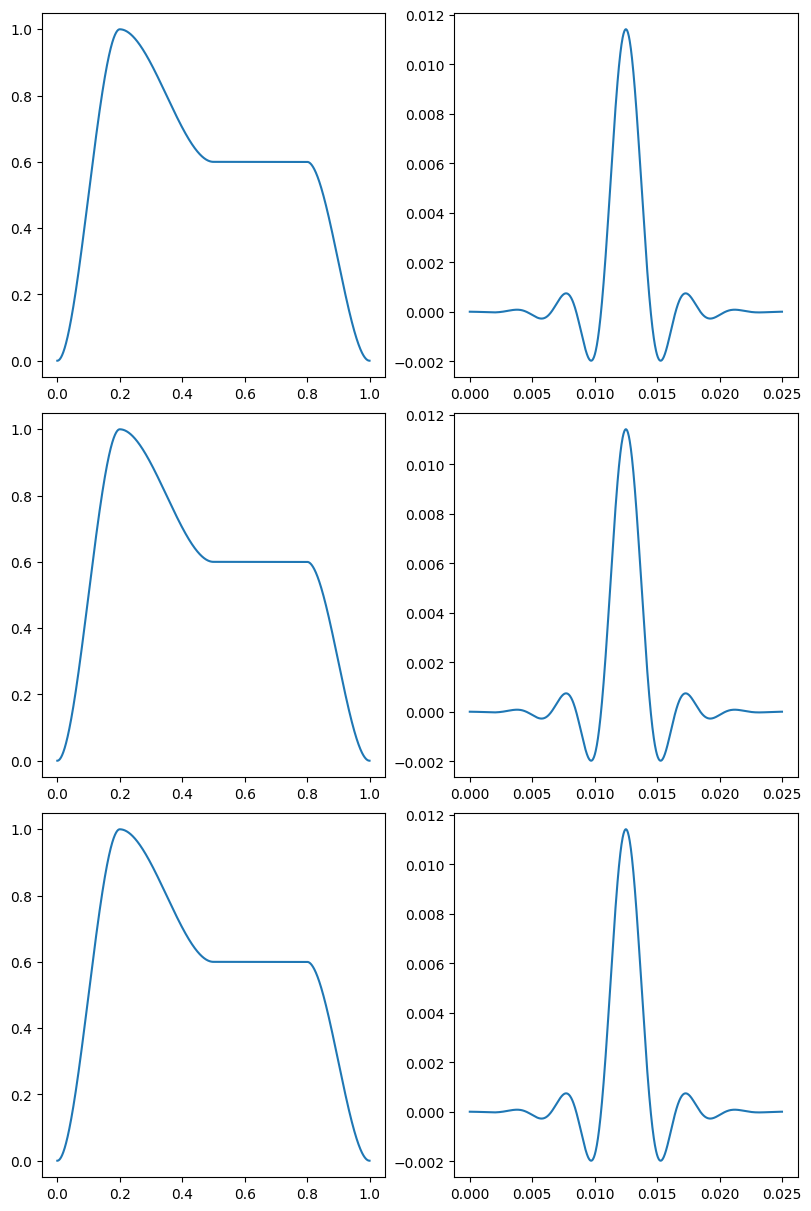

In [145]:
bpm = 90
time_signature = (4, 4)
sample_rate = 44100

bar_0 = Bar(notes = ["C4", "D4", "E4", "F4"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_0 = Oscillator(waveform = "sine", pitch = None, volume = 0.5, sample_rate = sample_rate)
adsrs_0 = ADSR(attack = 0.2, decay = 0.3, sustain = 0.3, sustain_level = 0.6, release = 0.2)
filters_0 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = sample_rate)
wave_0 = generate_wave(bar_0, oscillators_0, adsrs_0, None, bpm, sample_rate)

# pause = generate_pause(2/4, time_signature, bpm, sample_rate)

bar_1 = Bar(notes = ["E4", "F4", "G4", "A4"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_1 = Oscillator(waveform = "sine", pitch = None, volume = 0.75, sample_rate = sample_rate)
adsrs_1 = ADSR(attack = 0.2, decay = 0.3, sustain = 0.3, sustain_level = 0.6, release = 0.2)
filters_1 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = sample_rate)
wave_1 = generate_wave(bar_1, oscillators_1, adsrs_1, None, bpm, sample_rate)

bar_2 = Bar(notes = ["G4", "A4", "B4", "C5"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_2 = Oscillator(waveform = "sine", pitch = None, volume = 1, sample_rate = sample_rate)
adsrs_2 = ADSR(attack = 0.2, decay = 0.3, sustain = 0.3, sustain_level = 0.6, release = 0.2)
filters_2 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = sample_rate)
wave_2 = generate_wave(bar_2, oscillators_2, adsrs_2, None, bpm, sample_rate)

wave = wave_0 + wave_1 + wave_2
wave /= wave.max()

figure, axes = plt.subplots(3, 2, figsize = (8, 12), layout = "constrained")
axes[0, 0].plot(np.linspace(0, 1, sample_rate), adsrs_0.apply(np.ones(sample_rate)))
axes[0, 1].plot(np.linspace(0, filters_0.duration, filters_0.kernel.size), filters_0.kernel)
axes[1, 0].plot(np.linspace(0, 1, sample_rate), adsrs_1.apply(np.ones(sample_rate)))
axes[1, 1].plot(np.linspace(0, filters_0.duration, filters_1.kernel.size), filters_1.kernel)
axes[2, 0].plot(np.linspace(0, 1, sample_rate), adsrs_2.apply(np.ones(sample_rate)))
axes[2, 1].plot(np.linspace(0, filters_2.duration, filters_2.kernel.size), filters_2.kernel)

save("test", wave)
Audio("test.wav")

In [142]:
wave.max()

2.489647025305912

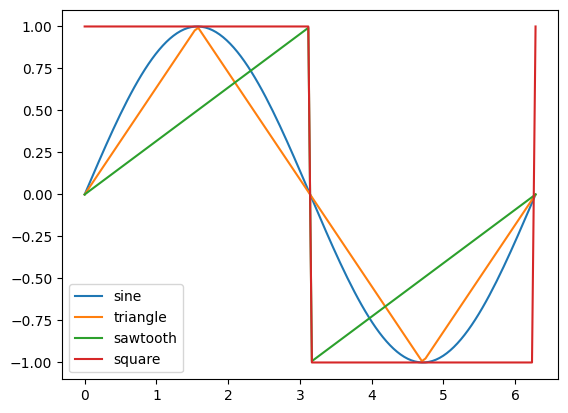

In [187]:
def generate_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")

def generate_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")

def generate_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")

triangle_wave = generate_triangle_wave()
sawtooth_wave = generate_sawtooth_wave()
square_wave = generate_square_wave()

amplitude, frequency, phase = 1, 1, 0

x = np.linspace(0, 2*np.pi, 128)
plt.plot(x, amplitude*np.sin(frequency*x + phase), label = "sine")
plt.plot(x, amplitude*triangle_wave(frequency*x + phase), label = "triangle")
plt.plot(x, amplitude*sawtooth_wave(frequency*x + phase), label = "sawtooth")
plt.plot(x, amplitude*square_wave(frequency*x + phase), label = "square")
plt.legend()